## EDA pentru dataset-ul hybrid.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Incarcam datele
df = pd.read_csv('mental_health_workplace_survey.csv')

# Verificam primele randuri
df.head()

,EmployeeID,Age,Gender,Country,JobRole,Department,YearsAtCompany,WorkHoursPerWeek,RemoteWork,BurnoutLevel,...,CommuteTime,HasMentalHealthSupport,ManagerSupportScore,HasTherapyAccess,MentalHealthDaysOff,SalaryRange,WorkLifeBalanceScore,TeamSize,CareerGrowthScore,BurnoutRisk
0,1001,50,Male,UK,Sales Associate,HR,14,47,No,3.37,...,117,No,3.15,Yes,8,40K-60K,8.82,6,9.20,0
1,1002,36,Male,Germany,Software Engineer,IT,1,59,Hybrid,7.39,...,8,Yes,4.40,Yes,4,80K-100K,2.80,45,8.46,1
2,1003,29,Non-binary,India,IT Admin,IT,13,59,Hybrid,7.10,...,75,No,3.63,No,6,80K-100K,7.28,7,7.96,1
3,1004,42,Male,Australia,HR Specialist,IT,15,31,Yes,4.18,...,43,Yes,4.50,Yes,9,60K-80K,1.31,11,8.90,0
4,1005,40,Male,Brazil,Customer Support,Support,6,34,Yes,8.28,...,58,Yes,5.51,Yes,6,<40K,1.17,18,8.88,1


In [ ]:
# Informatii generale
print(df.info())

# Descriere coloane numerice
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   EmployeeID              3000 non-null   int64  
 1   Age                     3000 non-null   int64  
 2   Gender                  3000 non-null   str    
 3   Country                 3000 non-null   str    
 4   JobRole                 3000 non-null   str    
 5   Department              3000 non-null   str    
 6   YearsAtCompany          3000 non-null   int64  
 7   WorkHoursPerWeek        3000 non-null   int64  
 8   RemoteWork              3000 non-null   str    
 9   BurnoutLevel            3000 non-null   float64
 10  JobSatisfaction         3000 non-null   float64
 11  StressLevel             3000 non-null   float64
 12  ProductivityScore       3000 non-null   float64
 13  SleepHours              3000 non-null   float64
 14  PhysicalActivityHrs     3000 non-null   float64
 15

In [7]:
# ==========================================
# CURATAREA DATELOR
# ==========================================

print("--- Incepem curatarea datelor ---")

# 1. Verificam daca avem duplicate, iar mai apoi le eliminam
duplicate_count = df.duplicated().sum()
print(f"Randuri duplicate gasite: {duplicate_count}")
if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicatele au fost eliminate!")

# 2. Verificam daca avem valori lipsa
print("\nValori lipsa per coloana:")
print(df.isnull().sum())
# Observam ca nu avem valori lipsa, deci nu este necesar sa le eliminam sau sa le completam / generam

# 3. Eliminam coloanele care nu ajuta algoritmul
# 'EmployeeID' este doar un numar de ordine
if 'EmployeeID' in df.columns:
    df = df.drop(columns=['EmployeeID'])
    print("\nColoana 'EmployeeID' a fost eliminata.")

print(f"\nDatele sunt curate! Tabelul final are {df.shape[0]} randuri si {df.shape[1]} coloane.")

--- Incepem curatarea datelor ---
Randuri duplicate gasite: 0

Valori lipsa per coloana:
Age                       0
Gender                    0
Country                   0
JobRole                   0
Department                0
YearsAtCompany            0
WorkHoursPerWeek          0
RemoteWork                0
BurnoutLevel              0
JobSatisfaction           0
StressLevel               0
ProductivityScore         0
SleepHours                0
PhysicalActivityHrs       0
CommuteTime               0
HasMentalHealthSupport    0
ManagerSupportScore       0
HasTherapyAccess          0
MentalHealthDaysOff       0
SalaryRange               0
WorkLifeBalanceScore      0
TeamSize                  0
CareerGrowthScore         0
BurnoutRisk               0
dtype: int64

Datele sunt curate! Tabelul final are 3000 randuri si 24 coloane.


# Week 4 - EDA

C:\Users\marco\AppData\Local\Temp\ipykernel_11004\3736741671.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='BurnoutRisk', palette='viridis')


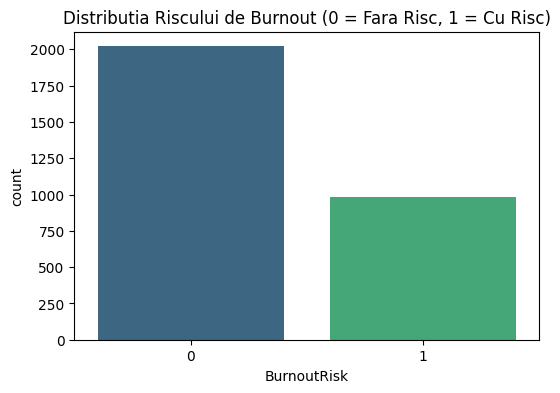

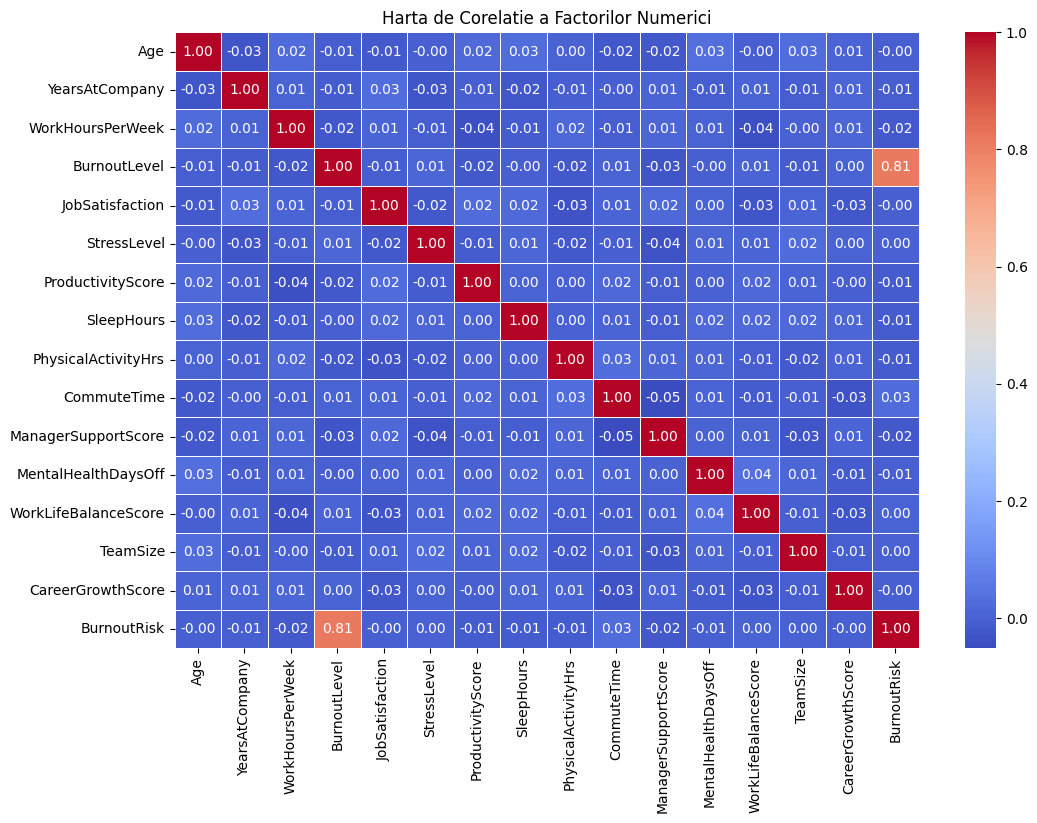

C:\Users\marco\AppData\Local\Temp\ipykernel_11004\3736741671.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='RemoteWork', y='StressLevel', palette='Set2')


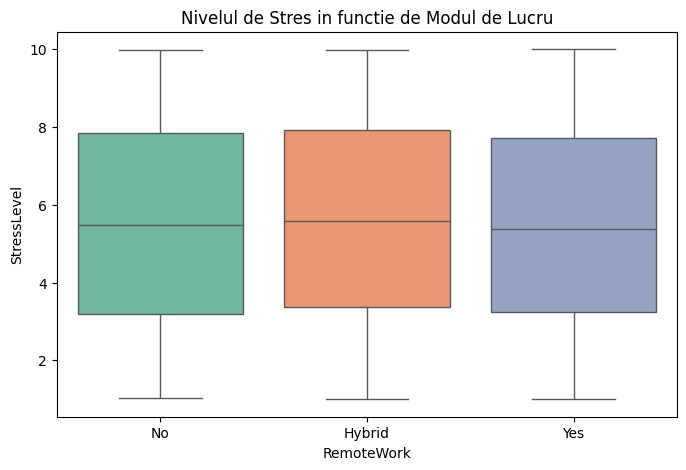

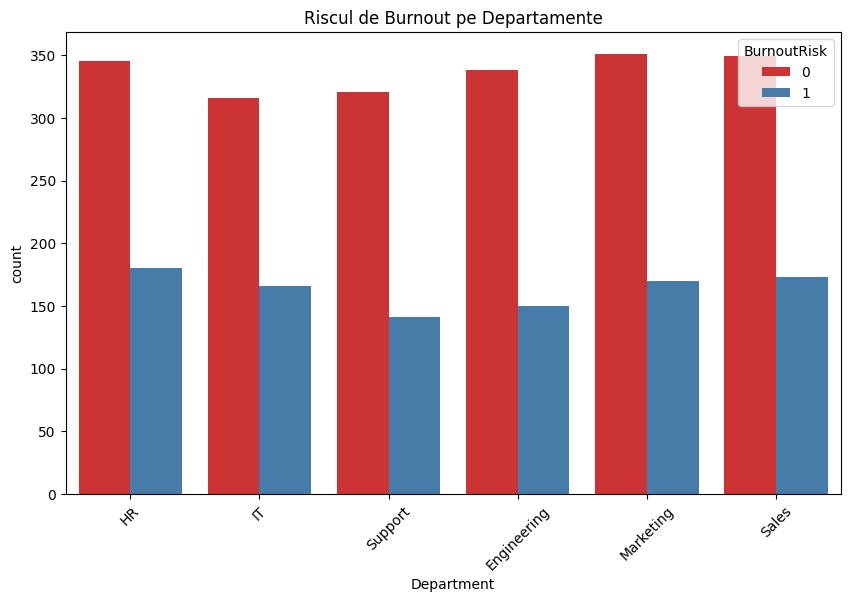

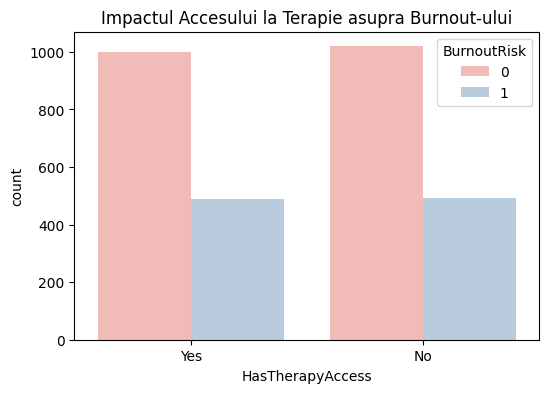

In [8]:
# --- 1. Distributia variabilei de risc pentru burnout ---
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='BurnoutRisk', palette='viridis')
plt.title("Distributia Riscului de Burnout (0 = Fara Risc, 1 = Cu Risc)")
plt.show()

# --- 2. Harta de Corelatie ---
plt.figure(figsize=(12, 8))
# Selectam doar coloanele numerice pentru a evita erori
numeric_cols = df.select_dtypes(include=['float64', 'int64'])

# Cream si afisam harta
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Harta de Corelatie a Factorilor Numerici')
plt.show()

# --- 3. Stresul vs. Munca Remote ---
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='RemoteWork', y='StressLevel', palette='Set2')
plt.title('Nivelul de Stres in functie de Modul de Lucru')
plt.show()

# --- 4. Riscul de Burnout pe Departamente ---
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Department', hue='BurnoutRisk', palette='Set1')
plt.title('Riscul de Burnout pe Departamente')
plt.xticks(rotation=45) # Rotim textul ca sa se citeasca usor
plt.show()

# --- 5. Riscul de Burnout in functie de Accesul la Terapie ---
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='HasTherapyAccess', hue='BurnoutRisk', palette='Pastel1')
plt.title('Impactul Accesului la Terapie asupra Burnout-ului')
plt.show()

# Week 6 - Ingineria caracteristicilor

In [ ]:
# 1. Eliminarea coloanei EmployeeID (nu are putere predictivă)
df_ml = df.drop(columns=['EmployeeID'])

# 2. Mapare SalaryRange (Variabilă ordinală)
salary_map = {'<40K': 0, '40K-60K': 1, '60K-80K': 2, '80K-100K': 3, '100K+': 4}
df_ml['SalaryRange'] = df_ml['SalaryRange'].map(salary_map)

# 3. Transformare variabile binare (Yes/No) în 0/1
binary_cols = ['HasMentalHealthSupport', 'HasTherapyAccess']
for col in binary_cols:
    df_ml[col] = df_ml[col].map({'Yes': 1, 'No': 0})

# 4. Encoding pentru RemoteWork (Hybrid/Yes/No)
df_ml = pd.get_dummies(df_ml, columns=['RemoteWork', 'Gender'], drop_first=True)

## Feature engineering

In [ ]:
# Raportul dintre orele de muncă și orele de somn (indicator de oboseală)
df_ml['WorkSleepRatio'] = df_ml['WorkHoursPerWeek'] / (df_ml['SleepHours'] * 7)

# Scor de "Timp pentru Sine" (Somn + Activitate Fizică)
df_ml['PersonalTimeScore'] = df_ml['SleepHours'] + df_ml['PhysicalActivityHrs']

# Impactul navetei raportat la satisfacția jobului
df_ml['CommuteStressFactor'] = df_ml['CommuteTime'] * (10 - df_ml['JobSatisfaction'])

# Experiența relativă la vârstă
df_ml['TenureRatio'] = df_ml['YearsAtCompany'] / df_ml['Age']

## Analiza Corelatiilor si Heatmap Extins

In [ ]:
plt.figure(figsize=(15, 10))
# Selectăm doar coloanele numerice pentru corelație
numeric_df = df_ml.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()

sns.heatmap(correlation_matrix[['BurnoutRisk']].sort_values(by='BurnoutRisk', ascending=False), 
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Corelația Factorilor cu Riscul de Burnout')
plt.show()

## Feature Importance

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Pregătirea datelor (eliminăm și BurnoutLevel dacă vrem să prezicem doar Riscul binar, 
# deoarece Level și Risk sunt aproape identice)
X = df_ml.drop(columns=['BurnoutRisk', 'BurnoutLevel', 'Country', 'JobRole', 'Department']) 
y = df_ml['BurnoutRisk']

# Antrenăm un model rapid pentru importanță
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

# Vizualizare
features = pd.DataFrame({'Feature': X.columns, 'Importance': rf.feature_importances_})
features = features.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=features, palette='viridis')
plt.title('Top Factori care Determină Riscul de Burnout')
plt.show()